# 05 — Product Performance, Conversion Funnel & Channels
Pareto/ABC product analysis, sessions→checkout funnel, device & referrer mix, and inventory risk flags.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
PINK, DARK, GREY = "#e75480", "#2d2d2d", "#999999"
RAW, PROC = "../data/raw/", "../data/processed/"
orders = pd.read_csv(PROC + "orders_clean.csv", parse_dates=["created_at", "order_date", "order_month"])
valid = orders[(~orders.cancelled) & (orders.total > 500)].copy()
daily = pd.read_csv(RAW + "daily_sales.csv", parse_dates=["day"])
fmt_pkr = mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K")

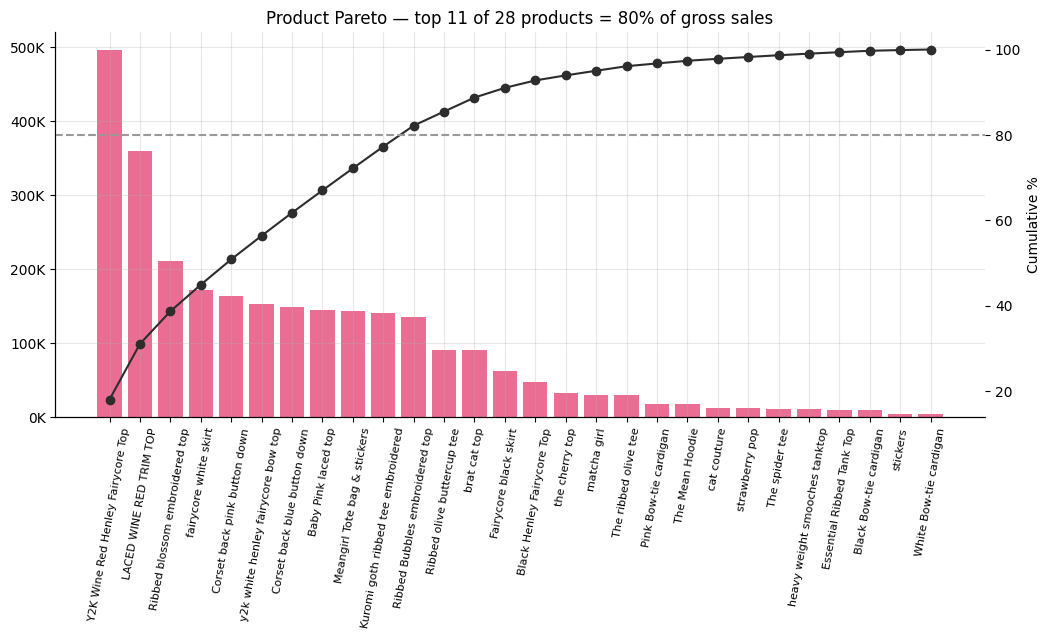

In [2]:
prod = pd.read_csv(RAW + "product_sales.csv").query("product_title != 'Test product'")
prod = prod.sort_values("gross_sales", ascending=False).reset_index(drop=True)
prod["cum_share"] = prod.gross_sales.cumsum() / prod.gross_sales.sum()
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(prod.product_title, prod.gross_sales, color=PINK, alpha=.85)
ax1.yaxis.set_major_formatter(fmt_pkr); ax1.tick_params(axis="x", rotation=80, labelsize=8)
ax2 = ax1.twinx(); ax2.plot(prod.product_title, prod.cum_share*100, "o-", color=DARK); ax2.grid(False)
ax2.axhline(80, color=GREY, ls="--"); ax2.set_ylabel("Cumulative %")
n80 = (prod.cum_share <= .8).sum() + 1
ax1.set_title(f"Product Pareto — top {n80} of {len(prod)} products = 80% of gross sales"); plt.show()

In [3]:
inv = pd.read_csv(RAW + "products_inventory.csv")
top = prod.head(12).merge(inv[["product_title","total_inventory"]], on="product_title", how="left")
top["stockout_risk"] = np.where(top.total_inventory <= 2, "SOLD OUT / CRITICAL",
                        np.where(top.total_inventory <= 7, "Low", "OK"))
top[["product_title","gross_sales","net_items_sold","total_inventory","stockout_risk"]]

,product_title,gross_sales,net_items_sold,total_inventory,stockout_risk
0,Y2K Wine Red Henley Fairycore Top,495730,130,0,SOLD OUT / CRITICAL
1,LACED WINE RED TRIM TOP,359705,113,5,Low
2,Ribbed blossom embroidered top,210380,60,5,Low
3,fairycore white skirt,171934,53,47,OK
4,Corset back pink button down,163689,37,18,OK
5,y2k white henley fairycore bow top,152649,36,7,Low
6,Corset back blue button down,148893,29,16,OK
7,Baby Pink laced top,144400,36,31,OK
8,Meangirl Tote bag & stickers,142800,197,-219,SOLD OUT / CRITICAL
9,Kuromi goth ribbed tee embroidered,140570,40,11,OK


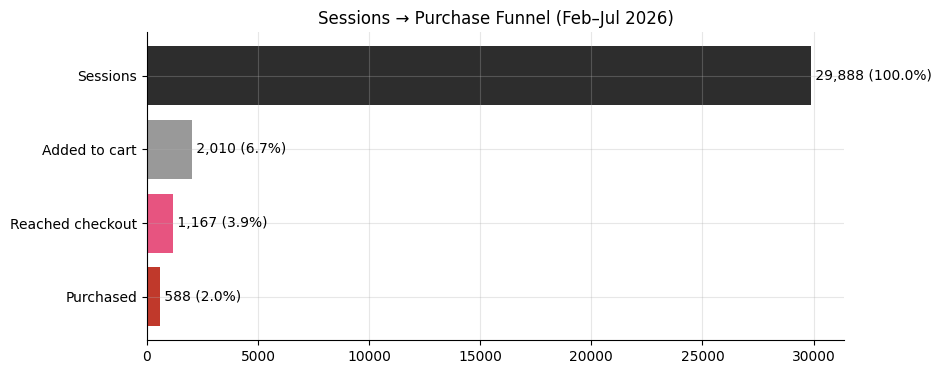

Cart rate 6.7% | Checkout completion 50.4% | Overall CVR 1.97%


In [4]:
# Conversion funnel (full period)
f = pd.read_csv(RAW + "daily_sessions_funnel.csv", parse_dates=["day"])
stages = [f.sessions.sum(), f.sessions_with_cart_additions.sum(),
          f.sessions_that_reached_checkout.sum(), f.sessions_that_completed_checkout.sum()]
labels = ["Sessions", "Added to cart", "Reached checkout", "Purchased"]
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(labels[::-1], stages[::-1], color=[DARK, GREY, PINK, "#c0392b"][::-1])
for i, (l, s) in enumerate(zip(labels[::-1], stages[::-1])):
    ax.text(s, i, f" {s:,} ({s/stages[0]:.1%})", va="center")
ax.set_title("Sessions → Purchase Funnel (Feb–Jul 2026)"); plt.show()
print(f"Cart rate {stages[1]/stages[0]:.1%} | Checkout completion {stages[3]/stages[2]:.1%} | Overall CVR {stages[3]/stages[0]:.2%}")

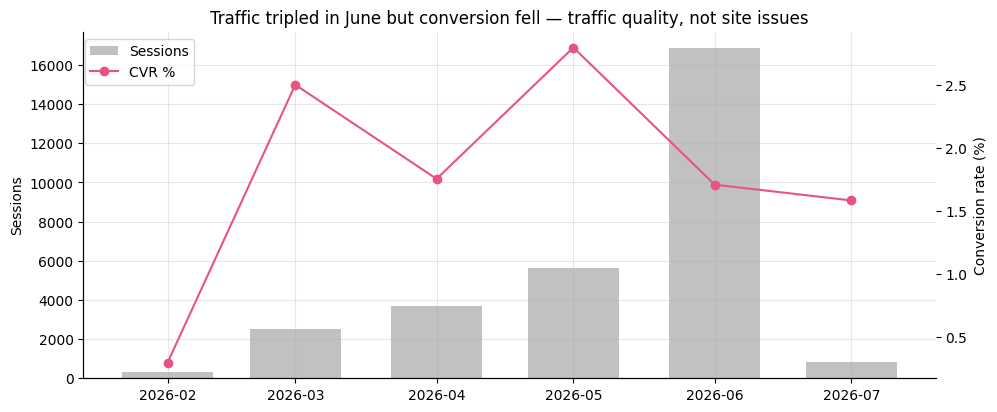

,sessions,purchases,cvr
day,,,
2026-02-01,334,1,0.003
2026-03-01,2520,63,0.025
2026-04-01,3705,65,0.018
2026-05-01,5653,158,0.028
2026-06-01,16855,288,0.017
2026-07-01,821,13,0.016


In [5]:
# Conversion rate vs traffic over time (the June story)
fm = f.set_index("day").resample("MS").agg(sessions=("sessions","sum"), purchases=("sessions_that_completed_checkout","sum"))
fm["cvr"] = fm.purchases / fm.sessions
fig, ax1 = plt.subplots()
ax1.bar(fm.index, fm.sessions, width=20, color=GREY, alpha=.6, label="Sessions")
ax2 = ax1.twinx(); ax2.plot(fm.index, fm.cvr*100, "o-", color=PINK, label="CVR %"); ax2.grid(False)
ax2.set_ylabel("Conversion rate (%)"); ax1.set_ylabel("Sessions")
ax1.set_title("Traffic tripled in June but conversion fell — traffic quality, not site issues")
fig.legend(loc="upper left", bbox_to_anchor=(.12,.88)); plt.show(); fm.round(3)

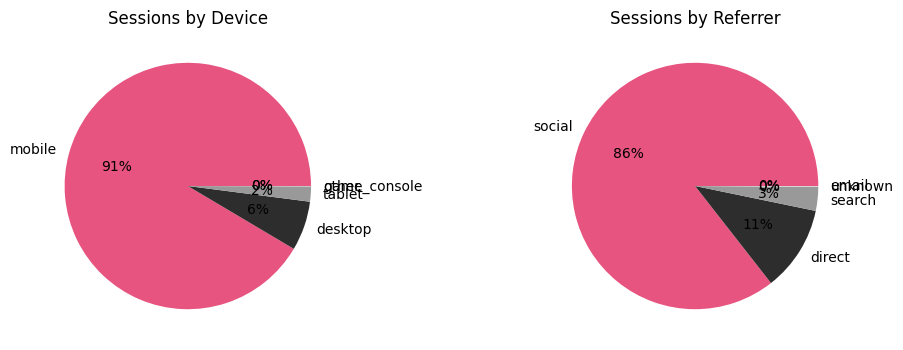

,orders,total_sales
order_referrer_source,,
direct/unknown,460,1866561.24
search,44,175814.01
social,128,469095.95


In [6]:
dev = pd.read_csv(RAW + "sessions_by_device.csv"); ref = pd.read_csv(RAW + "sessions_by_referrer.csv")
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].pie(dev.sessions, labels=dev.session_device_type, autopct="%1.0f%%",
            colors=[PINK, DARK, GREY, "#ccc", "#eee"]); axes[0].set_title("Sessions by Device")
axes[1].pie(ref.sessions, labels=ref.referrer_source, autopct="%1.0f%%",
            colors=[PINK, DARK, GREY, "#ccc", "#eee"]); axes[1].set_title("Sessions by Referrer")
plt.show()
sales_ref = pd.read_csv(RAW + "monthly_sales_by_referrer.csv")
sales_ref.groupby("order_referrer_source")[["orders","total_sales"]].sum()

### Findings
- **Pareto is extreme**: ~8 products generate 80% of gross sales. The two wine-red tops alone = **PKR 855K (31%)** of all-time gross sales. Depth on winners beats breadth of catalog.
- **Stockout risk on winners**: the #1 product (Y2K Wine Red Henley, 0 units) and #2 (Laced Wine Red Trim, 5 units) are effectively sold out while demand is peaking — the single most expensive operational issue in this data.
- **Funnel** (29.9K sessions → 2.0K carts → 1.2K checkouts → 588 purchases): overall CVR **1.97%**. Checkout completion is a healthy **50%**; the big leaks are session→cart (**6.7%**) and cart→checkout (**58%**). Better PDP content/sizing info and abandoned-cart recovery attack those stages.
- **Channel quality gap**: search sessions convert at ~**4.7%** (44 orders / 935 sessions) vs social at ~**0.5%** (128 / 25.6K) — a ~9x intent gap. Social builds reach; search/SEO and retargeting harvest it. 460 orders land as direct/unknown — add UTM discipline to Instagram bio/DM links to fix attribution.
- June: sessions 3x'd but CVR fell 2.8% → 1.7% — viral reach brought lower-intent browsers. Retarget warm audiences rather than buying more cold reach.
- The tote-bag freebie (PKR 142K fully discounted across 204 orders) worked as a branding/AOV play, not revenue.